# Study 787 — Heatwave-Utilities — for the quants 🔬

The full battery: one-sample *t* per window, a random-window placebo, a leave-one-out jackknife, the costed net leg, and a seeded synthetic positive control. Everything offline once cached; fingerprint `7e03507631b7`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from heatwave_utilities import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching XLU + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} summers resolved")


panel loaded; 27 of 27 summers resolved


## 1. One-sample *t* across independent summers

Each summer is one independent event, so the unit is a one-sample *t* of the per-year abnormal return — **not** a daily panel (which would fake precision).

In [2]:
for label, col in [('2wk into-heat','pre_s'),('1mo into-heat','pre_l'),('2wk past-peak','post_s'),('1mo past-peak','post_l')]:
    s = st.one_sample_t(inc[col].values)
    print(f'{label:<14s} n={s["n"]}  mean={s["mean"]*100:+.3f}%  sd={s["sd"]*100:.2f}%  t={s["t"]:+.3f}')

2wk into-heat  n=27  mean=-0.216%  sd=2.74%  t=-0.410
1mo into-heat  n=27  mean=-0.194%  sd=3.04%  t=-0.331
2wk past-peak  n=27  mean=+0.367%  sd=3.41%  t=+0.559
1mo past-peak  n=27  mean=+0.718%  sd=4.58%  t=+0.814


## 2. Random-window placebo — is the past-peak bump inside the luck cloud?

For each summer we redraw a random, non-peak 2-week window on XLU vs SPY and recompute the abnormal return; 20 seeds × 200 draws. If the observed mean sits in the tail of that null, it isn't ordinary tracking noise. Spoiler: it's centre-field.

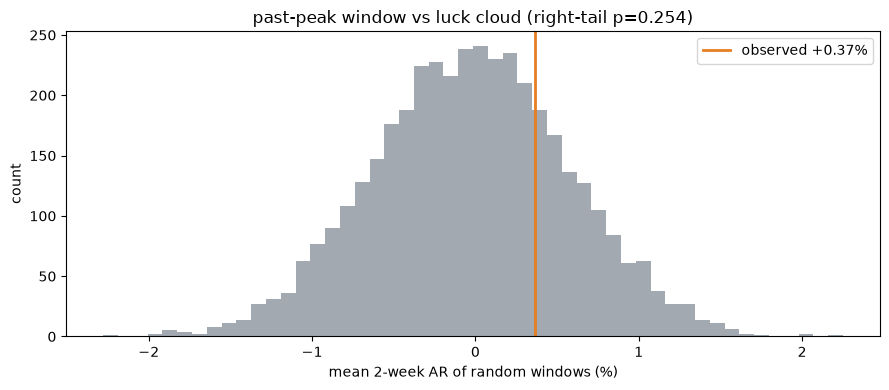

placebo: {'obs': 0.0037, 'placebo_mean': -0.0003, 'placebo_sd': 0.006, 'p_value': 0.2535, 'n_draws': 4000}


In [3]:
pl = st.placebo_pvalue(ev, prices, 'post_s', k=10, tail='right')
import numpy as np
xlu, spy = prices[dt.INSTRUMENT], prices[dt.BENCHMARK]
common = xlu.index.intersection(spy.index).sort_values()
rng = np.random.default_rng(999); draws = []
for _ in range(4000):
    vals = []
    for _e in range(int(inc.shape[0])):
        p = int(rng.integers(0, len(common)-11))
        vals.append(float(xlu.loc[common[p+10]]/xlu.loc[common[p]] - spy.loc[common[p+10]]/spy.loc[common[p]]))
    draws.append(np.mean(vals))
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(np.array(draws)*100, bins=50, color='#8b949e', alpha=0.8)
ax.axvline(pl['obs']*100, color='#e67e22', lw=2, label=f"observed {pl['obs']*100:+.2f}%")
ax.set_xlabel('mean 2-week AR of random windows (%)'); ax.set_ylabel('count')
ax.set_title(f"past-peak window vs luck cloud (right-tail p={pl['p_value']:.3f})"); ax.legend()
plt.tight_layout(); plt.show()
print('placebo:', {k: round(v,4) if isinstance(v,float) else v for k,v in pl.items()})

## 3. Jackknife — is the (tiny) past-peak tilt one good year, or broad?

In [4]:
x = inc['post_l'].values
jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
print(f'full-sample t = {st.one_sample_t(x)["t"]:+.3f}')
print(f'jackknife t range [{min(jk):+.3f}, {max(jk):+.3f}] over {len(x)} leave-one-out draws')

full-sample t = +0.814
jackknife t range [+0.365, +1.092] over 27 leave-one-out draws


## 4. Tradability — net of costs

Calendar-known entry, so the signal window and the tradable window are the same (gross vs net). The best cut is +0.72%/yr gross with *t* < 1 — and it only shrinks once you charge a couple of round-trips of cost.

In [5]:
ev10 = st.build_event_table(prices, cost_bps=10.0); inc10 = ev10[ev10['included']]
for base, label in [('post_l','1mo past-peak'),('pre_l','1mo into-heat')]:
    g = st.one_sample_t(inc[base].values); n5 = st.one_sample_t(inc[base+'_net'].values); n10 = st.one_sample_t(inc10[base+'_net'].values)
    print(f'{label:<14s} gross {g["mean"]*100:+.3f}% (t={g["t"]:+.2f})  net@5 {n5["mean"]*100:+.3f}% (t={n5["t"]:+.2f})  net@10 {n10["mean"]*100:+.3f}% (t={n10["t"]:+.2f})')

1mo past-peak  gross +0.718% (t=+0.81)  net@5 +0.618% (t=+0.70)  net@10 +0.518% (t=+0.59)
1mo into-heat  gross -0.194% (t=-0.33)  net@5 -0.294% (t=-0.50)  net@10 -0.394% (t=-0.67)


## 5. Synthetic positive control — the detector works, and the null is quiet

The one-sample-*t* detector must stay quiet on a planted-null world and recover a planted into-the-heat bump. At n = 27 the null is well-behaved (|*t*| ≥ 2 on ~1/20 seeds), and a planted ≥1% seasonal rally is caught cleanly — so the empty real result is a true absence, not a blind detector.

null: mean t=+0.20 sd=0.94  |t|>=2 in 1/20 seeds
planted +1%: mean AR +1.570%  t=+2.09
planted +2%: mean AR +2.570%  t=+3.43


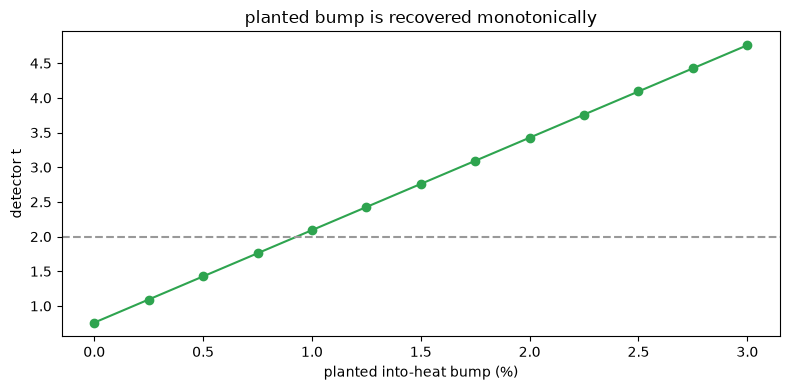

In [6]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=814+s, k=10)['t'] for s in range(20)])
print(f'null: mean t={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  |t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
for b in (0.01, 0.02):
    r = st.synthetic_detect(bump=b, seed=814, k=10)
    print(f'planted +{b*100:.0f}%: mean AR {r["mean"]*100:+.3f}%  t={r["t"]:+.2f}')
bumps = np.linspace(0, 0.03, 13)
ts = [st.synthetic_detect(bump=b, seed=814, k=10)['t'] for b in bumps]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(bumps*100, ts, 'o-', color='#2ea44f')
ax.axhline(2, color='0.6', ls='--'); ax.set_xlabel('planted into-heat bump (%)'); ax.set_ylabel('detector t')
ax.set_title('planted bump is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: None.** No window separates from noise — into-heat is a slightly-negative zero (|*t*| < 0.5) and the 'rally through the heat' past-peak window is directionally positive but tiny (+0.72%, *t* = +0.81, placebo right-tail p = 0.25, coin-flip 14/27). The synthetic control confirms the detector *would* have caught a real ≥1% seasonal rally — there just isn't one. **Tradability: Mirage.** Best cut +0.72%/yr gross, *t* < 1, decaying with costs, inside a 4-window search.